# MODEL PREDICTION ANALYSIS

The goal of this notebook is to derive meaningful insights from the model's predictions and to generate the official visualizations for the final report.

We will proceed in two stages:

- Report Generation: We then calculate the final metrics and generate the key figures (Recall curves, Cosine Similarity distributions) and tables used in the paper.

- Exploratory Analysis: We start by breaking down performance across different legal themes and source types to identify specific strengths and weaknesses in the benchmark.

### Necessary imports

In [8]:
import json
import glob
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go

### Helpers Methods

In [2]:
def load_data(files_pattern):
    data = []
    files = glob.glob(files_pattern)
    print(f"Found {len(files)} files to analyze.")
        
    for file_path in files:
        with open(file_path, 'r') as f:
            try:
                content = json.load(f)
                if isinstance(content, list):
                    items = content
                else:
                    items = [content]
                for i, item in enumerate(items):
                    data.append({
                        "id": i,
                        "question": item.get("question", ""),
                        "correct": item.get("correct", False),
                        "file": os.path.basename(file_path)
                    })
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    return pd.DataFrame(data)

def get_stats(column, df):
    summary = df.groupby(column).agg(
        count=("correct", "size"),
        Accuracy=("correct", "mean")
    ).reset_index()
    
    overall = pd.DataFrame([{
        column: "Overall",
        "count": df["correct"].size,
        "Accuracy": df["correct"].mean()
    }])

    final_summary = pd.concat([summary, overall], ignore_index=True)
    return final_summary, df

def print_stats(column, df):
    print(f"=============== Analysis by {column} ===============")
    print(df.to_string(formatters={
        'Accuracy': '{:,.2%}'.format
    }, index=False))

## Analysis of RAG Retrieval Performance

In this section, we analyze the retrieval behavior of the Retrieval-Augmented Generation (RAG) component on the IHL benchmark.  
For each benchmark question, we examine the **top-15 retrieved Customary IHL rules** produced by the embedding-based retriever.

All rules and queries are embedded using the **BAAI/bge-large-en** sentence embedding model.  
Retrieval is performed via cosine similarity between the question embedding and the pre-computed embeddings of the 161 Customary IHL rules.

The analysis focuses on:
- The rank position of the gold-standard rule
- Recall@$k$ for varying values of $k$
- The distribution of cosine similarity scores assigned to the correct rule

This allows us to evaluate the effectiveness of the retrieval component independently of the language model.

Loaded 271 IHL questions

===== GOLD RULE RANK STATISTICS =====
Mean rank:     1.95
Median rank:   1.0
Min rank:      1
Max rank:      15
Std deviation: 2.40
Recall@15:     90.41%



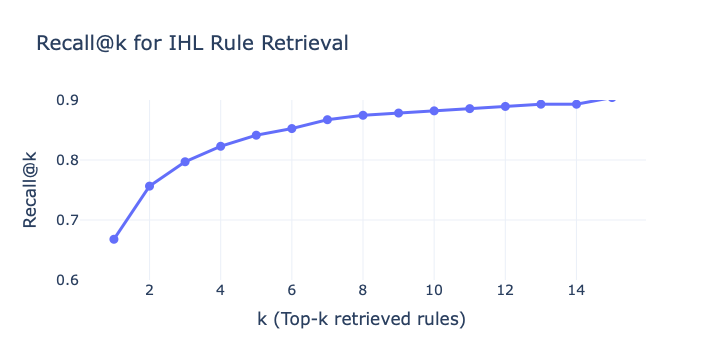

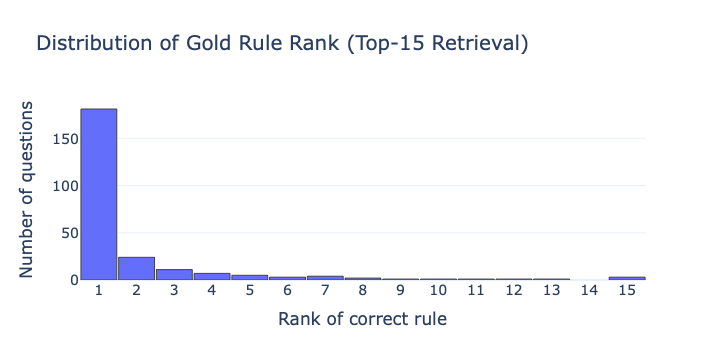

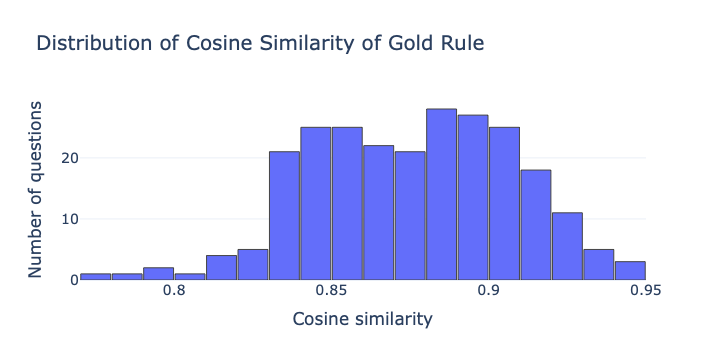

In [10]:
# ===============================
# Load RAG analysis JSON
# ===============================
with open("../evaluation/predictions/rag_analysis.json", "r", encoding="utf-8") as f:
    data = json.load(f)

results = data["results"]
total = len(results)

print(f"Loaded {total} IHL questions")

# ===============================
# Helper: normalize rule IDs
# ===============================
def normalize_rule_id(rule):
    """
    Accepts:
      - int (145)
      - str ("rule 145", "145")
    Returns:
      - "rule 145"
    """
    if isinstance(rule, int):
        return f"rule {rule}"
    rule = rule.lower().strip()
    if rule.startswith("rule"):
        return rule
    return f"rule {rule}"


# ===============================
# Compute Gold Rule Rank & Similarity
# ===============================
gold_ranks = []
gold_similarities = []
missing_gold = 0

for r in results:
    gold = normalize_rule_id(r["gold_source"])
    found = False

    for item in r["retrieved_sources"]:
        rid = normalize_rule_id(item["rule_id"])
        if rid == gold:
            gold_ranks.append(item["rank"])
            gold_similarities.append(item["similarity"])
            found = True
            break

    if not found:
        missing_gold += 1


# ===============================
# Rank statistics
# ===============================
gold_ranks_arr = np.array(gold_ranks)

mean_rank = gold_ranks_arr.mean()
median_rank = np.median(gold_ranks_arr)
min_rank = gold_ranks_arr.min()
max_rank = gold_ranks_arr.max()
std_rank = gold_ranks_arr.std()

print("\n===== GOLD RULE RANK STATISTICS =====")
print(f"Mean rank:     {mean_rank:.2f}")
print(f"Median rank:   {median_rank}")
print(f"Min rank:      {min_rank}")
print(f"Max rank:      {max_rank}")
print(f"Std deviation: {std_rank:.2f}")
print(f"Recall@15:     {len(gold_ranks_arr)/total*100:.2f}%")
print("====================================\n")

# ===============================
# Compute Recall@k
# ===============================
max_k = 15
recall_at_k = []

for k in range(1, max_k + 1):
    hits = 0
    for r in results:
        gold = normalize_rule_id(r["gold_source"])
        retrieved = r["retrieved_sources"][:k]
        retrieved_ids = [normalize_rule_id(x["rule_id"]) for x in retrieved]
        if gold in retrieved_ids:
            hits += 1
    recall_at_k.append(hits / total)

# ===============================
# Plot Recall@k
# ===============================
fig_recall = go.Figure()

fig_recall.add_trace(go.Scatter(
    x=list(range(1, max_k + 1)),
    y=recall_at_k,
    mode="lines+markers",
    marker=dict(size=9),
    line=dict(width=3),
    name="Recall@k"
))

fig_recall.update_layout(
    title="Recall@k for IHL Rule Retrieval",
    xaxis_title="k (Top-k retrieved rules)",
    yaxis_title="Recall@k",
    yaxis=dict(range=[0.6, 0.9]),
    template="plotly_white",
    hovermode="x unified",
    font=dict(size=14)
)

fig_recall.show()

# ===============================
# Plot 1 — Rank distribution
# ===============================
fig_rank = go.Figure()

fig_rank.add_trace(go.Histogram(
    x=gold_ranks,
    nbinsx=15,
    marker=dict(line=dict(width=1)),
))

fig_rank.update_layout(
    title="Distribution of Gold Rule Rank (Top-15 Retrieval)",
    xaxis_title="Rank of correct rule",
    yaxis_title="Number of questions",
    template="plotly_white",
    bargap=0.05,
    font=dict(size=14)
)

fig_rank.update_xaxes(dtick=1)
fig_rank.show()

# ===============================
# Plot 2 — Similarity distribution
# ===============================
fig_sim = go.Figure()

fig_sim.add_trace(go.Histogram(
    x=gold_similarities,
    nbinsx=25,
    marker=dict(line=dict(width=1)),
))

fig_sim.update_layout(
    title="Distribution of Cosine Similarity of Gold Rule",
    xaxis_title="Cosine similarity",
    yaxis_title="Number of questions",
    template="plotly_white",
    bargap=0.05,
    font=dict(size=14)
)

fig_sim.show()

The gold-standard rule has an average retrieval rank of 1.95, meaning it is typically retrieved within the top two results. Moreover, most gold rules exhibit cosine similarity scores above 0.82, indicating strong semantic alignment between questions and relevant IHL rules. These results confirm the effectiveness of the retrieval component for grounding downstream model predictions.

We conducted this experiment on both LLaMA and Qwen to evaluate the impact of different top-$k$ values and similarity-based filtering strategies on performance. Results were reported for ten different values of $k$. Overall, the observed variations in accuracy were limited, indicating that performance was largely insensitive to these parameter choices.

In [14]:
import plotly.graph_objects as go


# Data gotten from multiple benchmark evaluation with k= [1;10]

vKl = [1,2,3,4,5,6,7,8,9,10]

# Llama
source_accuracy_Llama = [38.22,36.94,38.43,39.07,40.76,40.76,42.46,42.46,43.74,43.3]
question_accuracy_llama = [25.27,25.27,24.42,24.63,26.33,24.63,25.05,25.05,25.48,26.3]
question_accuracy_llama = [x * 471 / 262 for x in question_accuracy_llama] # Taking into account that only 262 question are rule based

# Qwen
source_accuracy_qwen = [3.08,2.31,6.15,10.77,11.54,13.46,11.15,12.69,10.0,9.23]
question_accuracy_qwen = [59.23,57.31,58.46,58.46,58.46,59.23,58.46,58.46,58.46,59.62]

fig = go.Figure()

# ----- LLaMA / Legitron (BLUE) -----
fig.add_trace(go.Scatter(
    x=vKl, y=question_accuracy_llama,
    mode="lines+markers",
    name="LLaMA – Answer accuracy",
    line=dict(color="royalblue", width=3)
))

fig.add_trace(go.Scatter(
    x=vKl, y=source_accuracy_Llama,
    mode="lines+markers",
    name="LLaMA – Source accuracy",
    line=dict(color="royalblue", width=3, dash="dash")
))

# ----- Qwen (PURPLE) -----
fig.add_trace(go.Scatter(
    x=vKl, y=question_accuracy_qwen,
    mode="lines+markers",
    name="Qwen – Answer accuracy",
    line=dict(color="purple", width=3)
))

fig.add_trace(go.Scatter(
    x=vKl, y=source_accuracy_qwen,
    mode="lines+markers",
    name="Qwen – Source accuracy",
    line=dict(color="purple", width=3, dash="dash")
))

# ----- Layout -----
fig.update_layout(
    title="Impact of Top-K Retrieval on RAG Performance",
    xaxis_title="Top-K Retrieved Rules",
    yaxis_title="Accuracy (%)",
    template="plotly_white",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="center",
        x=0.5
    )
)

# ----- Logos as annotations -----
fig.add_layout_image(
    dict(
        source="llama_logo.png",
        xref="paper", yref="paper",
        x=0.02, y=1.12,
        sizex=0.08, sizey=0.08,
        xanchor="left", yanchor="bottom"
    )
)

fig.add_layout_image(
    dict(
        source="qwen_logo.png",
        xref="paper", yref="paper",
        x=0.25, y=1.12,
        sizex=0.08, sizey=0.08,
        xanchor="left", yanchor="bottom"
    )
)

fig.show()

We can see that the answer accuracy isn't really affected by the k's. With or without RAG, the models already have a great accuracy without knowing the rules. We can see though that the source accuracy rises a little with the k's.

## Theme Analysis 

- Here we try to analyze on which topic does the models tend to have success or to fail

In [3]:
THEME_KEYWORDS = {
    "Wounded, Sick & Dead": ["dead", "body", "bodies", "remains", "wounded", "sick", "medical", "hospital", "ambulance"],
    "Prisoners of War (POW)": ["prisoner", "captured", "detainee", "detention", "pow", "internment"],
    "Civilians": ["civilian", "protected person", "women", "children", "journalist", "humanitarian relief"],
    "Conduct of Hostilities": ["attack", "target", "weapon", "proportionality", "distinction", "military objective", "precautions"],
    "Occupation": ["occupation", "occupied", "occupying power"],
    "Emblems & Signs": ["emblem", "red cross", "red crescent", "flag", "insignia"],
}

def get_theme_by_keyword(question):
    q_lower = question.lower()
    
    for theme, keywords in THEME_KEYWORDS.items():
        if any(k in q_lower for k in keywords):
            return theme
            
    return "General / Other"

def get_themes(df):
    path = "../datasets/law_benchmark_data.json"
    df["Theme"] = ""
    with open(path, 'r') as f:
        try:
            content = json.load(f)
            if isinstance(content, list):
                items = content
            else:
                items = [content]
            for i, item in enumerate(items):
                theme = get_theme_by_keyword(item.get("question",""))
                df.loc[df["id"]==i,"Theme"] = theme
        except Exception as e:
            print(f"Error reading {path}: {e}")
    return df

def analyze_themes(file_path):
    df_raw = load_data(file_path)
    df_themed = get_themes(df_raw)
    COLUMN = "Theme"
    summary, df = get_stats(COLUMN, df_themed)
    print_stats(COLUMN, summary)
    return df

In [4]:
df_all_theme = analyze_themes("../evaluation/predictions/*.json")

Found 4 files to analyze.
=============== Analysis by Theme ===============
                 Theme  count Accuracy
             Civilians    288   75.69%
Conduct of Hostilities    272   70.22%
       Emblems & Signs     52   50.00%
       General / Other    976   67.42%
            Occupation     36   88.89%
Prisoners of War (POW)    120   75.83%
  Wounded, Sick & Dead    140   54.29%
               Overall   1884   68.58%


- Let's observe the impact of RAG on the llama and qwenbase model

#### LLAMA

In [13]:
df_llama_theme = analyze_themes("../evaluation/predictions/llama3.1-8B.json")

Found 1 files to analyze.
=============== Analysis by Theme ===============
                 Theme  count Accuracy
             Civilians     72   75.00%
Conduct of Hostilities     68   69.12%
       Emblems & Signs     13   46.15%
       General / Other    244   65.98%
            Occupation      9   66.67%
Prisoners of War (POW)     30   76.67%
  Wounded, Sick & Dead     35   51.43%
               Overall    471   66.88%


In [14]:
df_llama_RAG_theme = analyze_themes("../evaluation/predictions/llama3.1-8B_RAG.json")

Found 1 files to analyze.
=============== Analysis by Theme ===============
                 Theme  count Accuracy
             Civilians     72   72.22%
Conduct of Hostilities     68   61.76%
       Emblems & Signs     13   53.85%
       General / Other    244   65.98%
            Occupation      9  100.00%
Prisoners of War (POW)     30   73.33%
  Wounded, Sick & Dead     35   45.71%
               Overall    471   65.61%


#### QWEN

In [16]:
df_qwen_theme = analyze_themes("../evaluation/predictions/qwen2.5-7B.json")

Found 1 files to analyze.
=============== Analysis by Theme ===============
                 Theme  count Accuracy
             Civilians     72   76.39%
Conduct of Hostilities     68   75.00%
       Emblems & Signs     13   46.15%
       General / Other    244   67.62%
            Occupation      9  100.00%
Prisoners of War (POW)     30   80.00%
  Wounded, Sick & Dead     35   60.00%
               Overall    471   70.28%


In [17]:
df_qwen_RAG_theme = analyze_themes("../evaluation/predictions/qwen2.5-7B_RAG.json")

Found 1 files to analyze.
=============== Analysis by Theme ===============
                 Theme  count Accuracy
             Civilians     72   79.17%
Conduct of Hostilities     68   75.00%
       Emblems & Signs     13   53.85%
       General / Other    244   70.08%
            Occupation      9   88.89%
Prisoners of War (POW)     30   73.33%
  Wounded, Sick & Dead     35   60.00%
               Overall    471   71.55%


## Source Analysis

- We analyse for which type of sources does the models succeed in general, and the impact of using RAG to provide the IHL rules to the model

In [20]:
def get_source_category(sources):
    """
    Classifies a list of sources into 'Rules', 'Reports', or 'Mixed'.
    """
    if not sources:
        return "Unknown"

    has_rule = False
    has_report = False
    s_lower = str(sources).lower()
    if "rule" in s_lower:
        has_rule = True
    elif "icrc" in s_lower:
        has_report = True

    if has_rule and not has_report:
        return "IHL Rules"
    elif has_report and not has_rule:
        return "ICRC Reports"
    elif has_rule and has_report:
        return "Mixed (Rule + Report)"
    else:
        return "Other"

def get_sources(df):
    path = "../datasets/law_benchmark_data.json"
    df["Source"] = ""
    with open(path, 'r') as f:
        try:
            content = json.load(f)
            if isinstance(content, list):
                items = content
            else:
                items = [content]
            for i, item in enumerate(items):
                source = get_source_category(item.get("source", None))
                df.loc[df["id"]==i,"Source"] = source
        except Exception as e:
            print(f"Error reading {path}: {e}")
    return df

def analyze_sources(file_path):
    df_raw = load_data(file_path)
    df_sourced = get_sources(df_raw)
    COLUMN = "Source"
    summary, df = get_stats(COLUMN, df_sourced)
    print_stats(COLUMN, summary)
    return df

In [21]:
df_all = analyze_sources("../evaluation/predictions/*.json")

Found 4 files to analyze.
=============== Analysis by Source ===============
      Source  count Accuracy
ICRC Reports    804   88.31%
   IHL Rules   1048   53.91%
     Unknown     32   53.12%
     Overall   1884   68.58%


- Let's observe the impact of RAG on the llama and qwen base model

#### LLAMA

In [24]:
df_llama_source = analyze_sources("../evaluation/predictions/llama3.1-8B.json")

Found 1 files to analyze.
=============== Analysis by Source ===============
      Source  count Accuracy
ICRC Reports    201   84.08%
   IHL Rules    262   54.20%
     Unknown      8   50.00%
     Overall    471   66.88%


In [25]:
df_llama_RAG_source = analyze_sources("../evaluation/predictions/llama3.1-8B_RAG.json")

Found 1 files to analyze.
=============== Analysis by Source ===============
      Source  count Accuracy
ICRC Reports    201   88.06%
   IHL Rules    262   48.09%
     Unknown      8   75.00%
     Overall    471   65.61%


#### QWEN

In [27]:
df_qwen_source = analyze_sources("../evaluation/predictions/qwen2.5-7B.json")

Found 1 files to analyze.
=============== Analysis by Source ===============
      Source  count Accuracy
ICRC Reports    201   90.55%
   IHL Rules    262   55.34%
     Unknown      8   50.00%
     Overall    471   70.28%


In [28]:
df_qwen_RAG_source = analyze_sources("../evaluation/predictions/qwen2.5-7B_RAG.json")

Found 1 files to analyze.
=============== Analysis by Source ===============
      Source  count Accuracy
ICRC Reports    201   90.55%
   IHL Rules    262   58.02%
     Unknown      8   37.50%
     Overall    471   71.55%


- We see that some cells have sources labeled as Unknown, in this case it means that no source ground truth was provided for that question :

In [30]:
# Questions without sources
UNKNOWN_QUESTIONS = [17,21,24,30,74,119,399,431]

In [31]:
df_llama_source.loc[UNKNOWN_QUESTIONS,"correct"]

17     False
21     False
24     False
30      True
74     False
119     True
399     True
431     True
Name: correct, dtype: bool

In [32]:
df_llama_RAG_source.loc[UNKNOWN_QUESTIONS,"correct"]

17     False
21     False
24      True
30      True
74      True
119     True
399     True
431     True
Name: correct, dtype: bool

In [33]:
df_qwen_source.loc[UNKNOWN_QUESTIONS,"correct"]

17     False
21     False
24      True
30      True
74      True
119    False
399    False
431     True
Name: correct, dtype: bool

In [34]:
df_qwen_RAG_source.loc[UNKNOWN_QUESTIONS,"correct"]

17     False
21     False
24     False
30      True
74      True
119     True
399    False
431    False
Name: correct, dtype: bool